In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime','RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_train[input_features], df_train[output_targets], test_size=0.2, random_state=42
)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Create separate models for each target variable
models = {}
for i, target_variable in enumerate(output_targets):
    # Build a Gradient Boosting regression model
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    
    # Train the model for the current target variable
    model.fit(X_train_scaled, y_train[target_variable])
    
    # Store the trained model
    models[target_variable] = model

# Make predictions on the test set and evaluate each model separately
for target_variable, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate and display accuracy metrics
    mse = mean_squared_error(y_test[target_variable], y_pred)
    r2 = r2_score(y_test[target_variable], y_pred)
    mae = mean_absolute_error(y_test[target_variable], y_pred)
    variance_explained = 100 * (1 - mse / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse:.2f}, R-squared: {r2:.2%}, Mean Absolute Error: {mae:.2f}, Variance Explained: {variance_explained:.2f}%')

# Print the total number of training data points
print(f'Total Training Data Points: {X_train_scaled.shape[0]}')


OSD.longitude - Mean Squared Error: 0.01, R-squared: 39.86%, Mean Absolute Error: 0.04, Variance Explained: 39.86%
OSD.latitude - Mean Squared Error: 0.01, R-squared: 40.09%, Mean Absolute Error: 0.05, Variance Explained: 40.09%
OSD.altitude [ft] - Mean Squared Error: 4970.70, R-squared: 40.14%, Mean Absolute Error: 38.48, Variance Explained: 40.14%
OSD.pitch - Mean Squared Error: 6.27, R-squared: 47.02%, Mean Absolute Error: 1.56, Variance Explained: 47.02%
OSD.roll - Mean Squared Error: 2.45, R-squared: 26.35%, Mean Absolute Error: 1.03, Variance Explained: 26.35%
OSD.yaw - Mean Squared Error: 6237.12, R-squared: 27.69%, Mean Absolute Error: 62.05, Variance Explained: 27.69%
Total Training Data Points: 29648


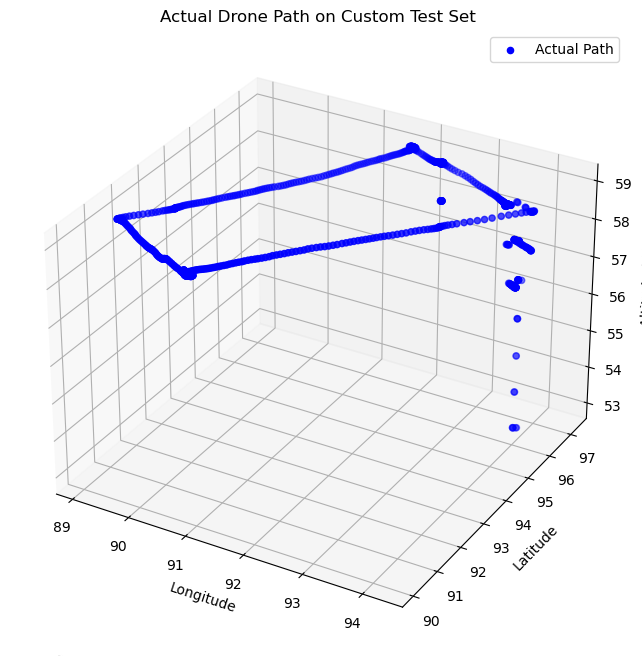

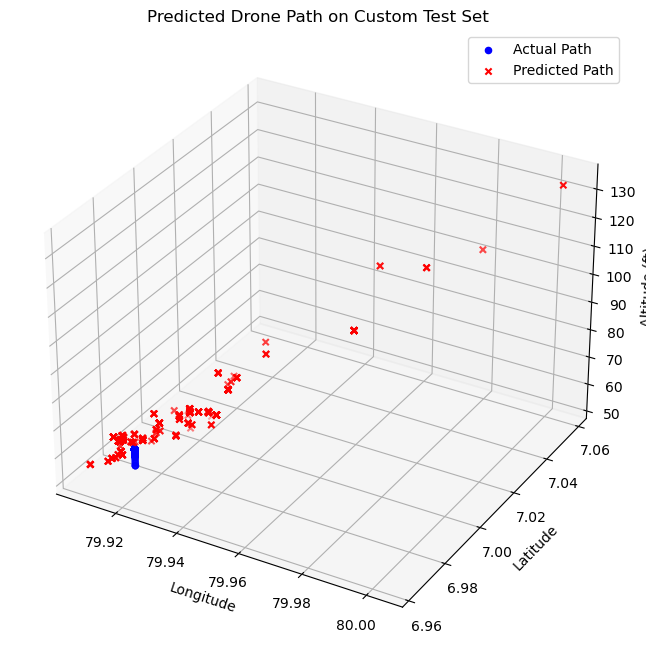

29648


In [6]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = {}
for target_variable, model in models.items():
    y_pred_custom[target_variable] = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_predicted_custom.scatter(y_pred_custom['OSD.longitude'], y_pred_custom['OSD.latitude'], y_pred_custom['OSD.altitude [ft]'], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()

print(X_train_scaled.shape[0])
